In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

OUT_DIR = Path("/home/jpillai/projects/skarf-experiments/results/intrinsic_benchmarks")

# colors
PYSPI_COLOR = "#1f77b4"
SKARF_LAG0  = "#ff7f0e"
SKARF_LAG1  = "#ffbb78"

In [ ]:
def plot_density_metric(density_df, metric_col, y_label, out_dir=None):
    pyspi_d = density_df[density_df["method"] == "pyspi"].copy()
    skarf_d = density_df[density_df["method"] == "skarf"].copy()

    pyspi_d = pyspi_d[np.isfinite(pyspi_d[metric_col].astype(float))]
    skarf_d = skarf_d[np.isfinite(skarf_d[metric_col].astype(float))]

    pyspi_order = (
        pyspi_d.groupby("func")[metric_col].median()
        .sort_values(ascending=False).index.tolist()
    )
    skarf_order = (
        skarf_d.groupby("func")[metric_col].median()
        .sort_values(ascending=False).index.tolist()
    )

    fig, (ax_p, ax_s) = plt.subplots(
        1, 2,
        figsize=(max(len(pyspi_order) * 0.35 + 2, 10),
                 max(len(skarf_order) * 0.5 + 2, 6)),
        sharey=True,
        gridspec_kw={"width_ratios": [len(pyspi_order), len(skarf_order)]}
    )

    FLIER=dict(marker="o", markerfacecolor="none", markeredgecolor="black",
            markersize=2, alpha=0.4, linestyle="none")
    MEDIAN=dict(color="black", linewidth=1.2)
    BOX=dict(linewidth=0.8)
    WHISKER=dict(linewidth=0.8)
    CAP=dict(linewidth=0.8)

    # pyspi panel
    bp = ax_p.boxplot(
        [pyspi_d[pyspi_d["func"] == f][metric_col].dropna().values for f in pyspi_order],
        positions=range(len(pyspi_order)), widths=0.5, patch_artist=True,
        flierprops=FLIER, medianprops=MEDIAN, boxprops=BOX,
        whiskerprops=WHISKER, capprops=CAP,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(PYSPI_COLOR); patch.set_alpha(0.7)

    ax_p.set_xticks(range(len(pyspi_order)))
    ax_p.set_xticklabels(pyspi_order, rotation=90, ha="right", fontsize=6)
    ax_p.set_ylabel(y_label)
    ax_p.set_title("(a) PySPI metrics (0.8 sparsity)")
    ax_p.margins(y=0.05)

    # skarf panel
    lags = sorted(skarf_d["lag"].dropna().unique())
    n_lags = len(lags)
    width = 0.35
    lag_colors = {lags[0]: SKARF_LAG0, lags[1]: SKARF_LAG1} if n_lags > 1 else {lags[0]: SKARF_LAG0}
    lag_hatch  = {lags[0]: "",          lags[1]: "///"}      if n_lags > 1 else {lags[0]: ""}

    for lag_idx, lag in enumerate(lags):
        lag_sub = skarf_d[skarf_d["lag"] == lag]
        offsets = [i + (lag_idx - (n_lags - 1) / 2) * width for i in range(len(skarf_order))]
        bp = ax_s.boxplot(
            [lag_sub[lag_sub["func"] == f][metric_col].dropna().values for f in skarf_order],
            positions=offsets, widths=width * 0.85, patch_artist=True,
            flierprops=FLIER, medianprops=MEDIAN, boxprops=BOX,
            whiskerprops=WHISKER, capprops=CAP,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(lag_colors[lag])
            patch.set_hatch(lag_hatch[lag])
            patch.set_alpha(0.7)

    ax_s.set_xticks(range(len(skarf_order)))
    ax_s.set_xticklabels(skarf_order, rotation=90, ha="right", fontsize=7)
    ax_s.set_title("(b) skarf metrics (0.8 sparsity)")
    ax_s.margins(y=0.05)

    legend_elements = [
        mpatches.Patch(facecolor=PYSPI_COLOR, alpha=0.7, label="pyspi"),
        mpatches.Patch(facecolor=SKARF_LAG0,  alpha=0.7, label="skarf lag 0"),
        mpatches.Patch(facecolor=SKARF_LAG1,  alpha=0.7, hatch="///", label="skarf lag 1"),
    ]
    fig.legend(handles=legend_elements, loc="upper center", ncol=3,
               frameon=True, fontsize=8, bbox_to_anchor=(0.5, 1.02))
    plt.suptitle(y_label, y=1.04, fontsize=11)
    sns.despine()
    plt.tight_layout()

    if out_dir:
        plt.savefig(out_dir / f"{metric_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

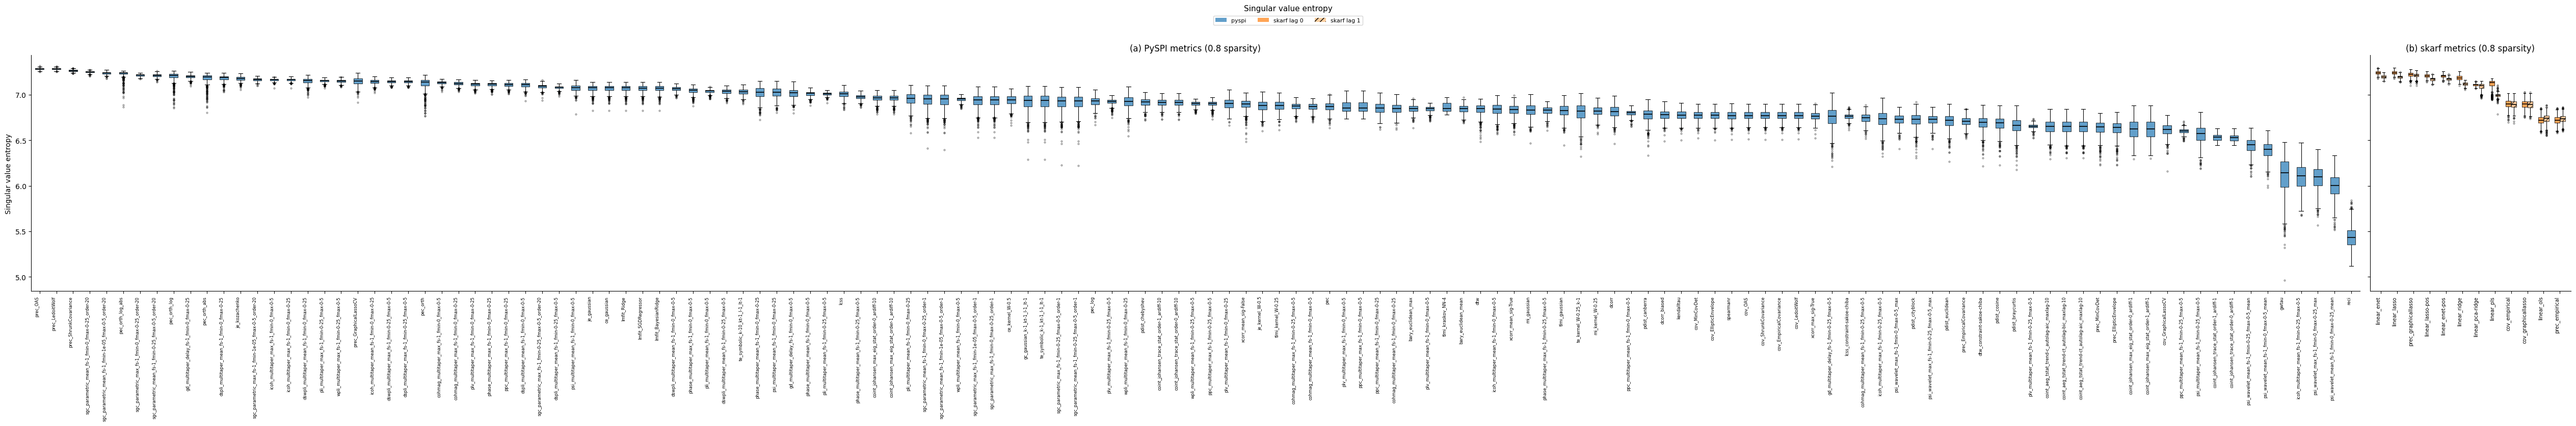

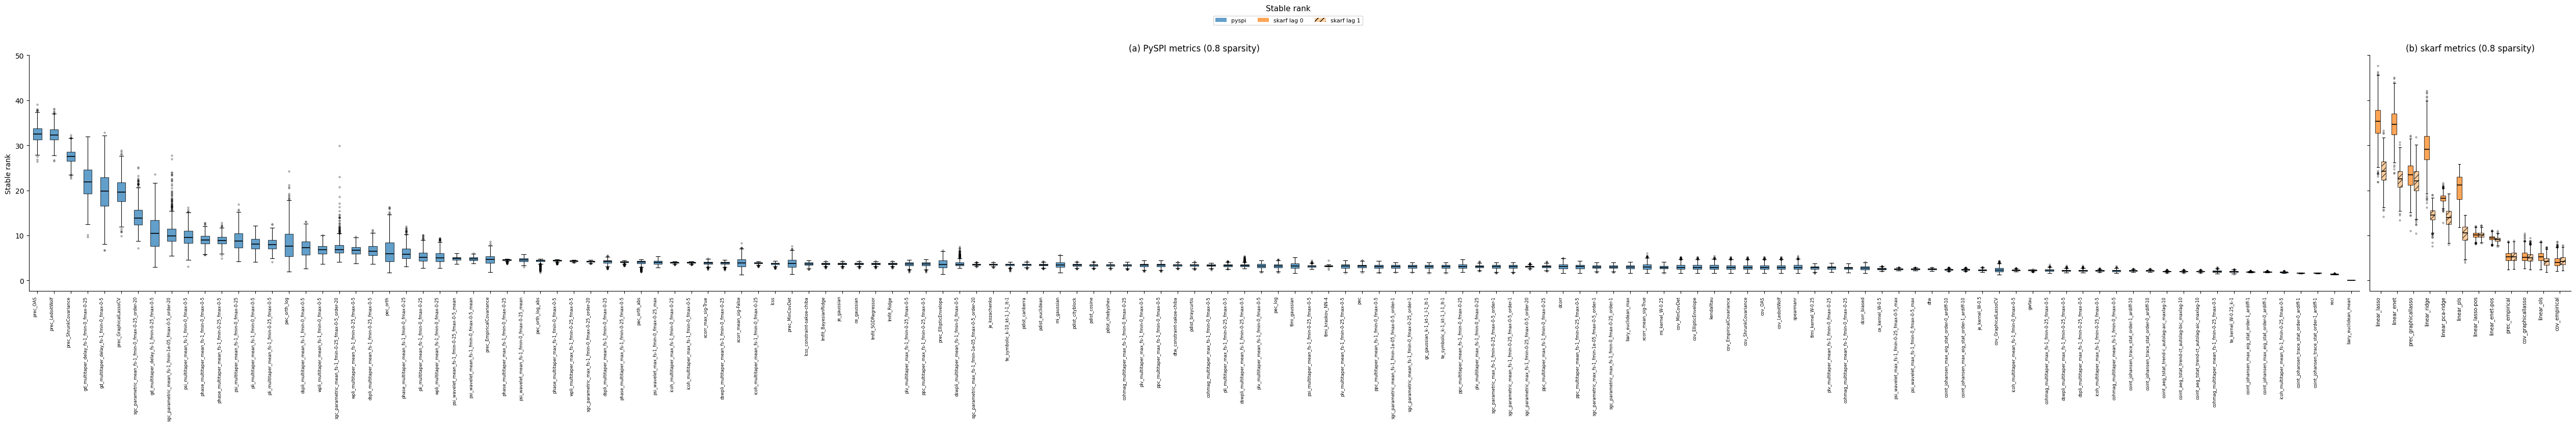

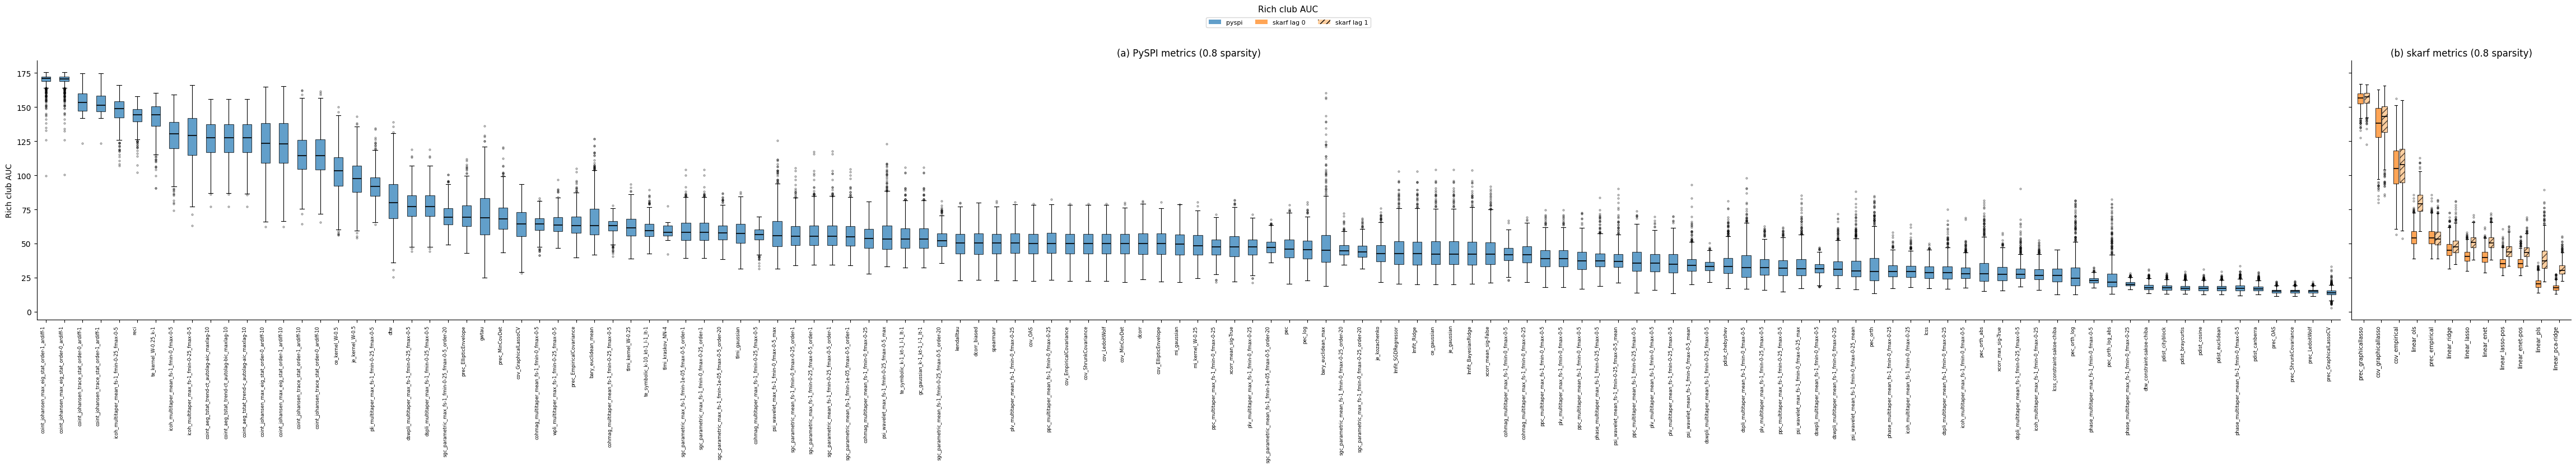

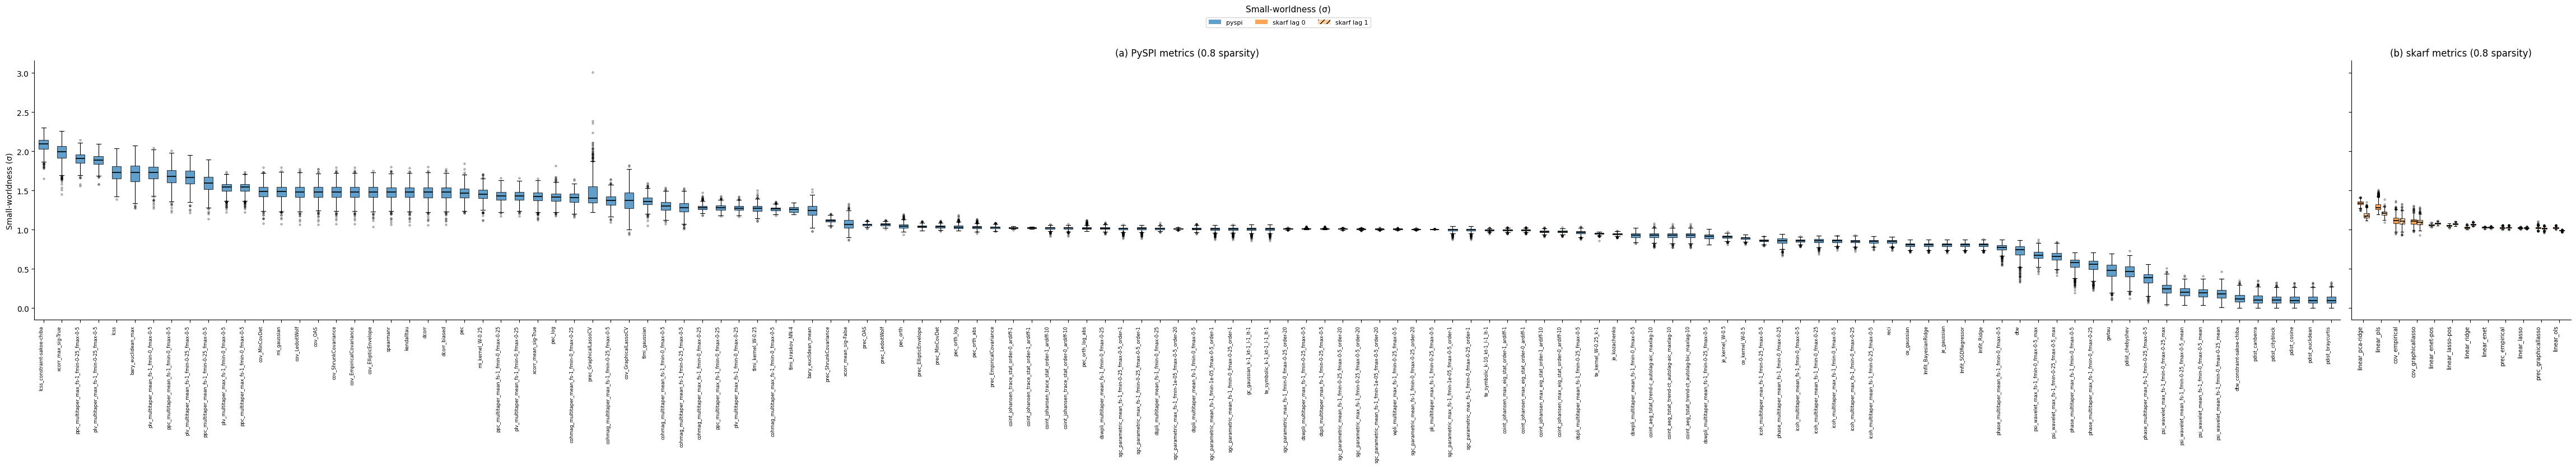

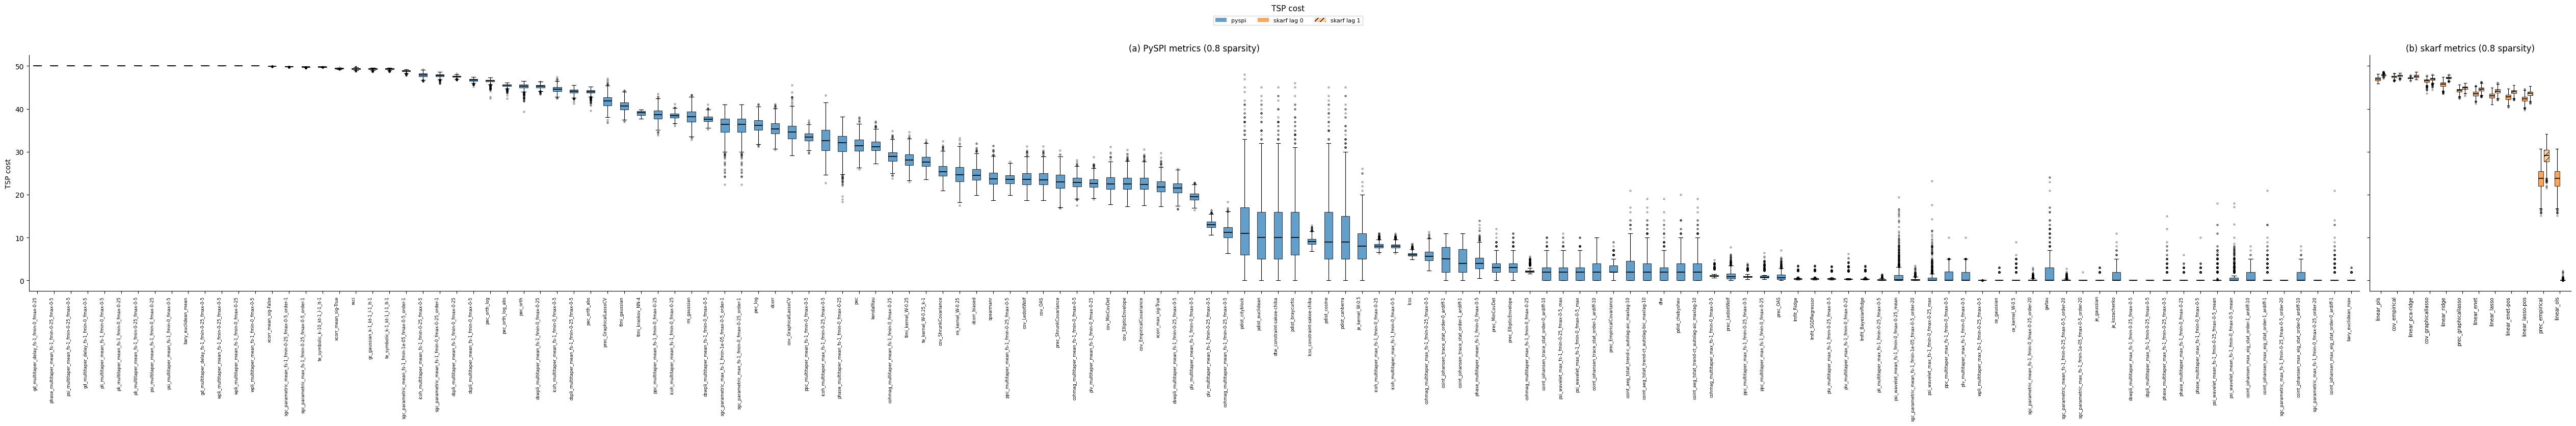

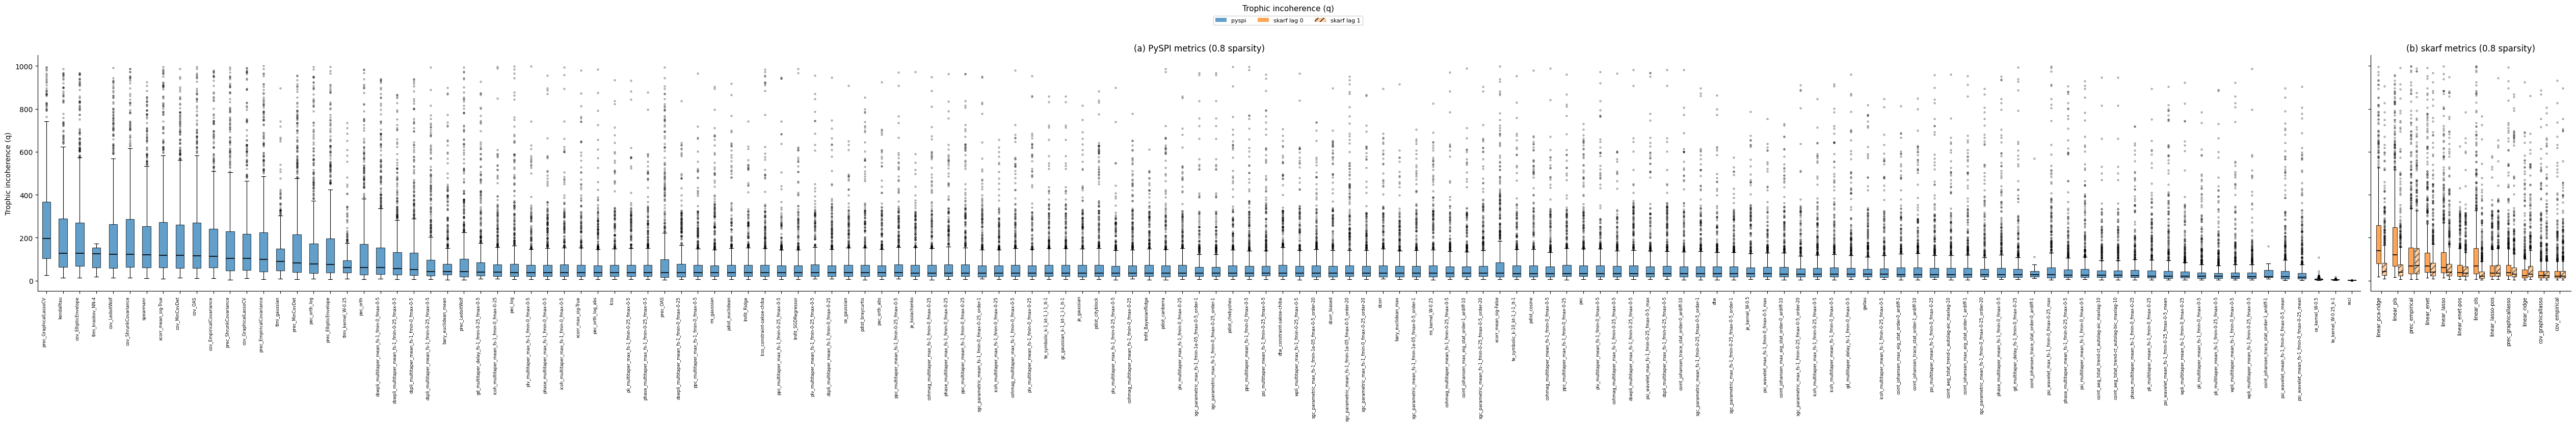

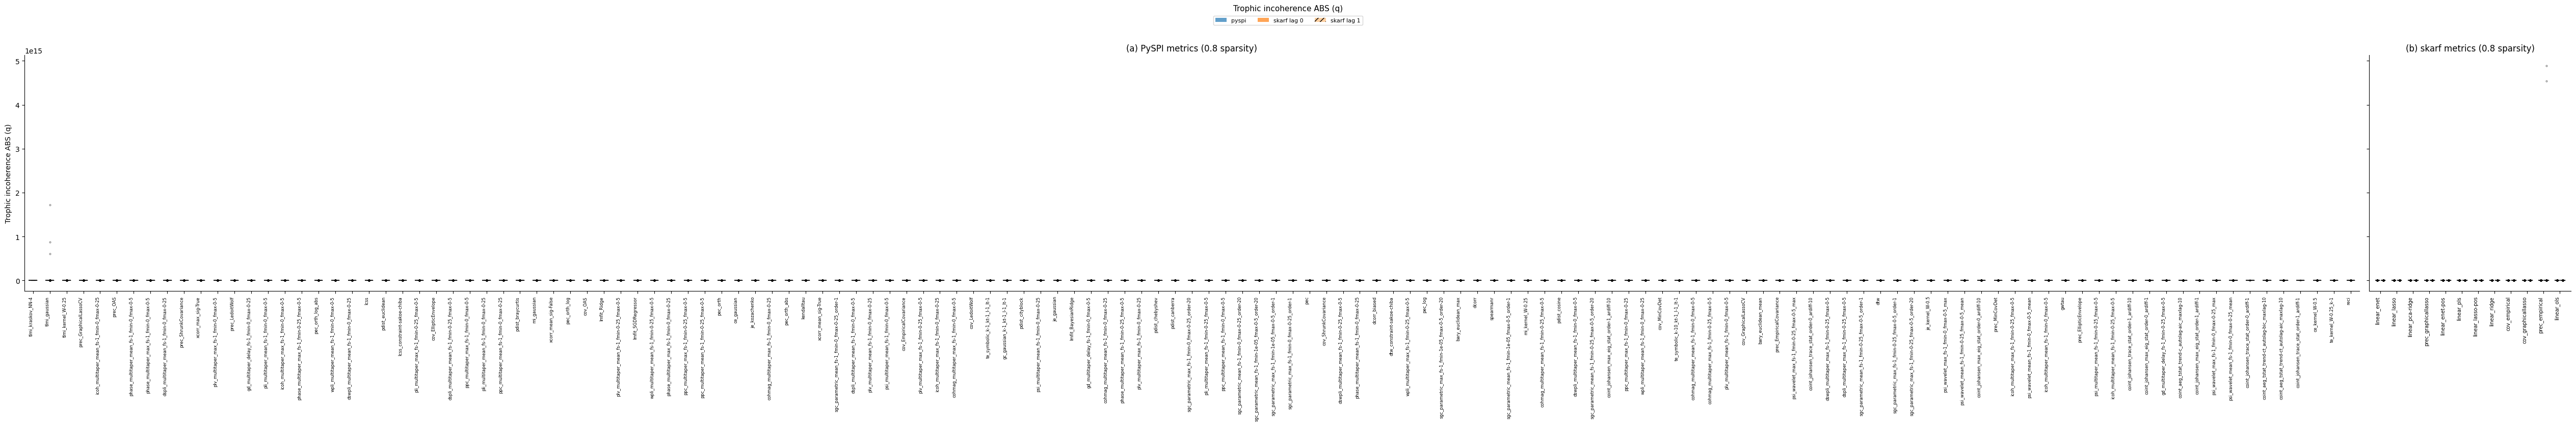

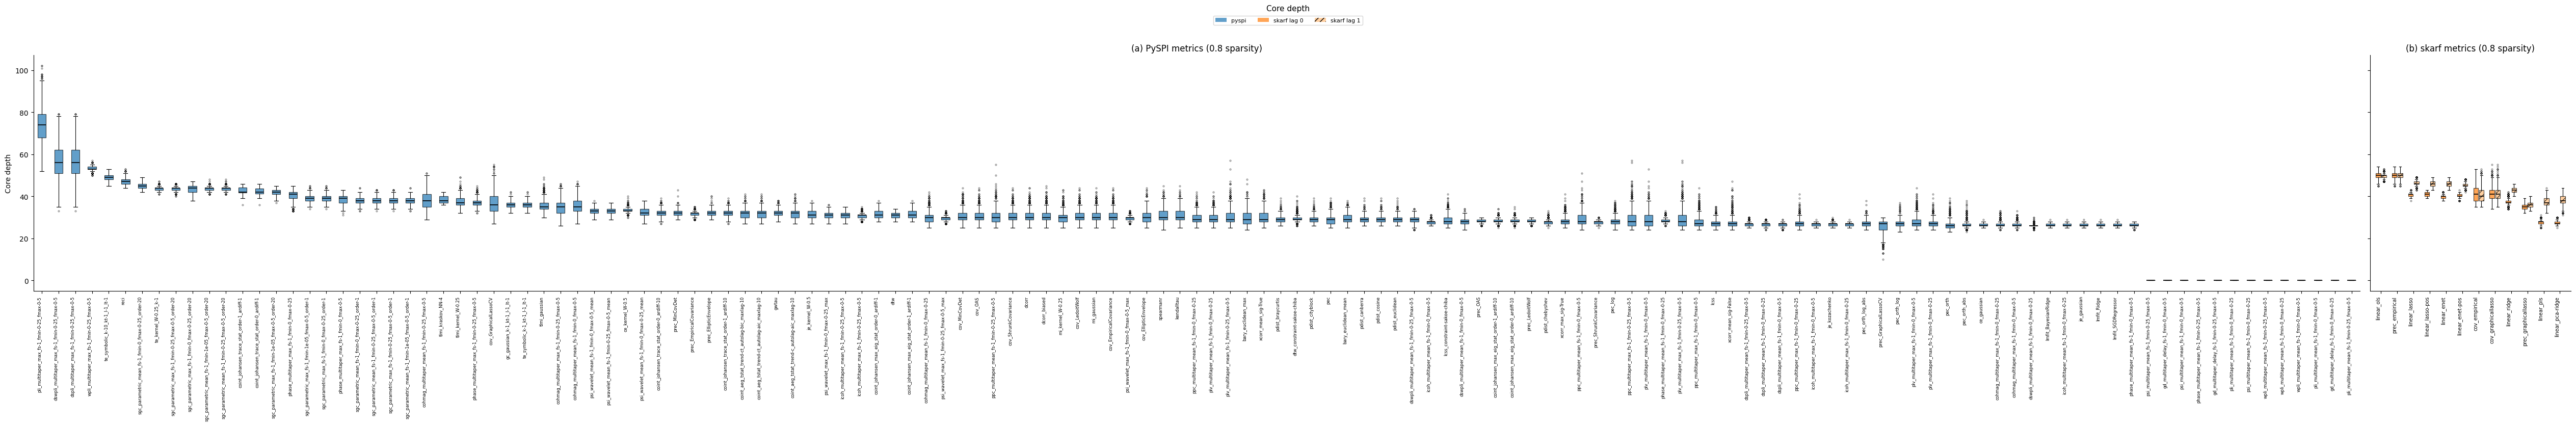

In [ ]:
density_df = pd.read_parquet(OUT_DIR / "info_density.parquet")

# clean trophic incoherence outliers for plotting only
density_df_clean = density_df.copy()
density_df_clean.loc[density_df_clean["trophic_incoherence"] > 1000, "trophic_incoherence"] = np.nan

METRICS_TO_PLOT = {
    "sv_entropy": "Singular value entropy",
    "stable_rank": "Stable rank",
    "rich_club_auc": "Rich club AUC",
    "small_worldness": "Small-worldness (σ)",
    "tsp_cost": "TSP cost",
    "trophic_incoherence": "Trophic incoherence (q)",
    "trophic_incoherence_abs": "Trophic incoherence ABS (q)",
    "core_depth": "Core depth",
}

for col, label in METRICS_TO_PLOT.items():
    plot_density_metric(density_df_clean, col, label, out_dir=OUT_DIR)

In [ ]:
# to-do: plot based on "top 20" so it is not so crowded